Install chronos:

pip install chronos-forecasting


In [18]:
import pandas as pd
import seaborn as sns
sns.set_theme(palette="colorblind")

import torch
from skforecast.datasets import fetch_dataset
from skforecast.foundation import FoundationModel, ForecasterFoundation
from skforecast.model_selection import TimeSeriesFold, backtesting_foundation
from sklearn.metrics import root_mean_squared_error

# Load data

In [19]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/bike_sharing_dataset_clean.csv", 
                 parse_dates=["date_time"], index_col="date_time")

# remove the time zone information
df.index = pd.DatetimeIndex([i.replace(tzinfo=None) for i in df.index])

df = df.asfreq('h')

df.head()

,holiday,workingday,weather,temp,atemp,hum,windspeed,users,month,hour,weekday
2011-01-01 00:00:00,0.0,0.0,clear,9.84,14.395,81.0,0.0,16.0,1,0,5
2011-01-01 01:00:00,0.0,0.0,clear,9.02,13.635,80.0,0.0,40.0,1,1,5
2011-01-01 02:00:00,0.0,0.0,clear,9.02,13.635,80.0,0.0,32.0,1,2,5
2011-01-01 03:00:00,0.0,0.0,clear,9.84,14.395,75.0,0.0,13.0,1,3,5
2011-01-01 04:00:00,0.0,0.0,clear,9.84,14.395,75.0,0.0,1.0,1,4,5


# Train-test split

In [20]:
# 80% for training
train_size = int(df.shape[0]*0.8)

# Set up TimeSeriesFold

In [21]:
cv = TimeSeriesFold(
         steps=24,
         initial_train_size=train_size,
         refit=False
     )

# Baseline

In [22]:
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection._validation import backtesting_forecaster


last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results_lv, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['users'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_lv.index = ["Last-Value"]
results_lv

  0%|          | 0/147 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Last-Value,412.611249,336.979196


# Model development and evaluation

In [23]:
estimator = FoundationModel(model_id="autogluon/chronos-2-small", context_length=500)
forecaster = ForecasterFoundation(estimator=estimator)

In [24]:
metrics_chronos, backtest_predictions = backtesting_foundation(
    forecaster=forecaster,
    series=df['users'],
    exog=df[["weather", "temp", "hum", "windspeed"]],
    cv=cv,
    metric=[root_mean_squared_error, 'mean_absolute_error'],
    suppress_warnings=True
)

metrics_chronos

  0%|          | 0/147 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
0,70.621233,40.726701


In [25]:
backtest_predictions.head()

,level,fold,pred
2012-08-07 19:00:00,users,0,632.606812
2012-08-07 20:00:00,users,0,482.280396
2012-08-07 21:00:00,users,0,342.509644
2012-08-07 22:00:00,users,0,262.492798
2012-08-07 23:00:00,users,0,159.793716


<Axes: >

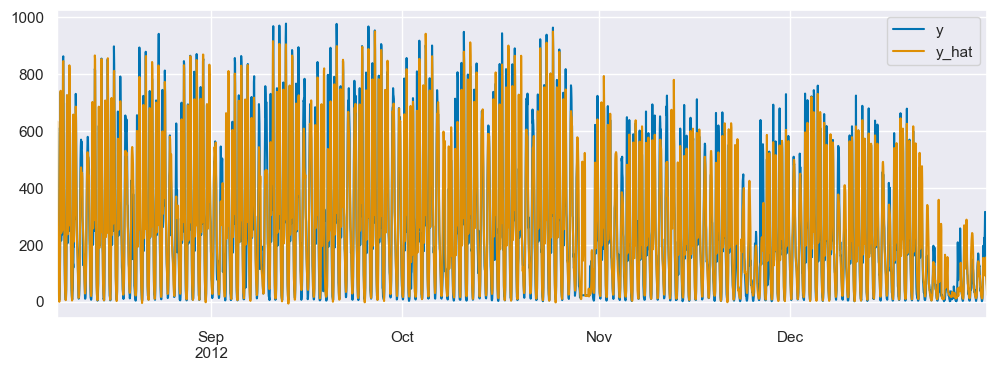

In [26]:
tdf = pd.DataFrame({"y": df.iloc[train_size:, df.columns.get_loc("users")], 
                    "y_hat": backtest_predictions["pred"]})
tdf.plot(figsize=(12,4))

<Axes: >

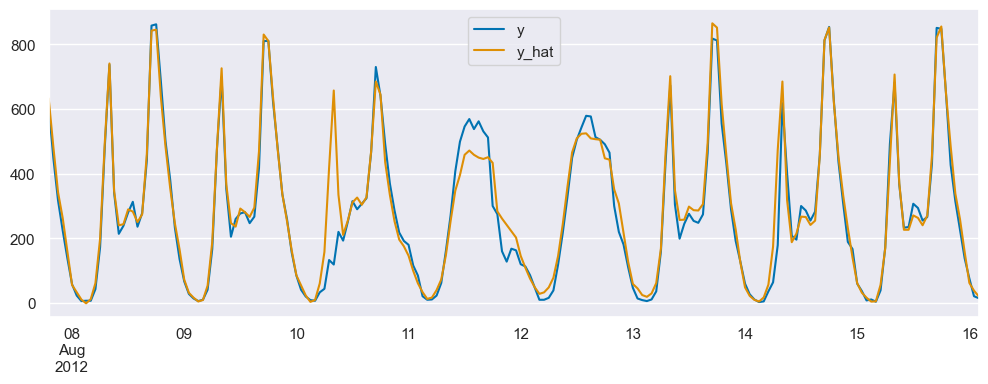

In [27]:
tdf.iloc[:200,:].plot(figsize=(12,4))

# Feature importances

In [28]:
# feature ablation

covariates = ["weather", "temp", "hum", "windspeed"]

rmse_main = metrics_chronos.loc[0, "root_mean_squared_error"]
mae_main = metrics_chronos.loc[0, "mean_absolute_error"]

importances_rmse = {}
importances_mae = {}

for feature in covariates:
    X_ablate = df[covariates].copy()
    X_ablate = X_ablate.drop(columns=[feature])

    # make predictions with the ablated feature
    metrics, backtest_predictions = backtesting_foundation(
        forecaster=forecaster,
        series=df['users'],
        exog=X_ablate,
        cv=cv,
        metric=[root_mean_squared_error, 'mean_absolute_error'],
        suppress_warnings=True
    )

    rmse = metrics.loc[0, "root_mean_squared_error"]
    mae = metrics.loc[0, "mean_absolute_error"]

    importances_rmse[feature] = rmse - rmse_main
    importances_mae[feature] = mae - mae_main   

  0%|          | 0/147 [00:00<?, ?it/s]

  0%|          | 0/147 [00:00<?, ?it/s]

  0%|          | 0/147 [00:00<?, ?it/s]

  0%|          | 0/147 [00:00<?, ?it/s]

In [29]:
importances_df = pd.DataFrame({"feature": covariates,
                               "importance_rmse": [importances_rmse[x] for x in covariates],
                               "importance_mae": [importances_mae[x] for x in covariates]})
importances_df.sort_values("importance_rmse", ascending=False)

,feature,importance_rmse,importance_mae
2,hum,2.683021,0.697569
1,temp,2.198173,1.151706
0,weather,2.090340,0.945317
3,windspeed,-1.180346,-0.432618


# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf